# Notebook 04 — Taxonomy Analysis and Visualisation
## Project: HallucinationGuard
## Paper: P1 — Taxonomy and Benchmark of LLM Hallucination

### Purpose
Produce all publication-ready figures for Paper 1 using
the scored responses from Notebook 03.

### Figures produced
- fig02_hallucination_rate_by_category.png  (Table III in paper)
- fig03_metric_comparison_radar.png         (Figure 2 in paper)
- fig04_bertscore_distribution.png          (Figure 3 in paper)
- fig05_domain_risk_heatmap.png             (Figure 4 in paper)

### Author
Monishwaran | Sathyabama Institute of Science and Technology

In [1]:
# ─── Cell 2: Setup ────────────────────────────────────────────────────────────

!pip install matplotlib seaborn pandas tabulate -q

import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from google.colab import files

os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Publication style settings
# These ensure all figures meet IEEE standards
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.family': 'serif',        # IEEE uses serif fonts
    'axes.spines.top': False,
    'axes.spines.right': False
})

print("Setup complete. Upload flan_t5_base_hallucination_scores.json")
uploaded = files.upload()

with open('flan_t5_base_hallucination_scores.json') as f:
    scores = json.load(f)

df = pd.DataFrame(scores)
print(f"Loaded {len(df)} scored responses.")


Setup complete. Upload flan_t5_base_hallucination_scores.json


Saving flan_t5_base_hallucination_scores.json to flan_t5_base_hallucination_scores.json
Loaded 817 scored responses.


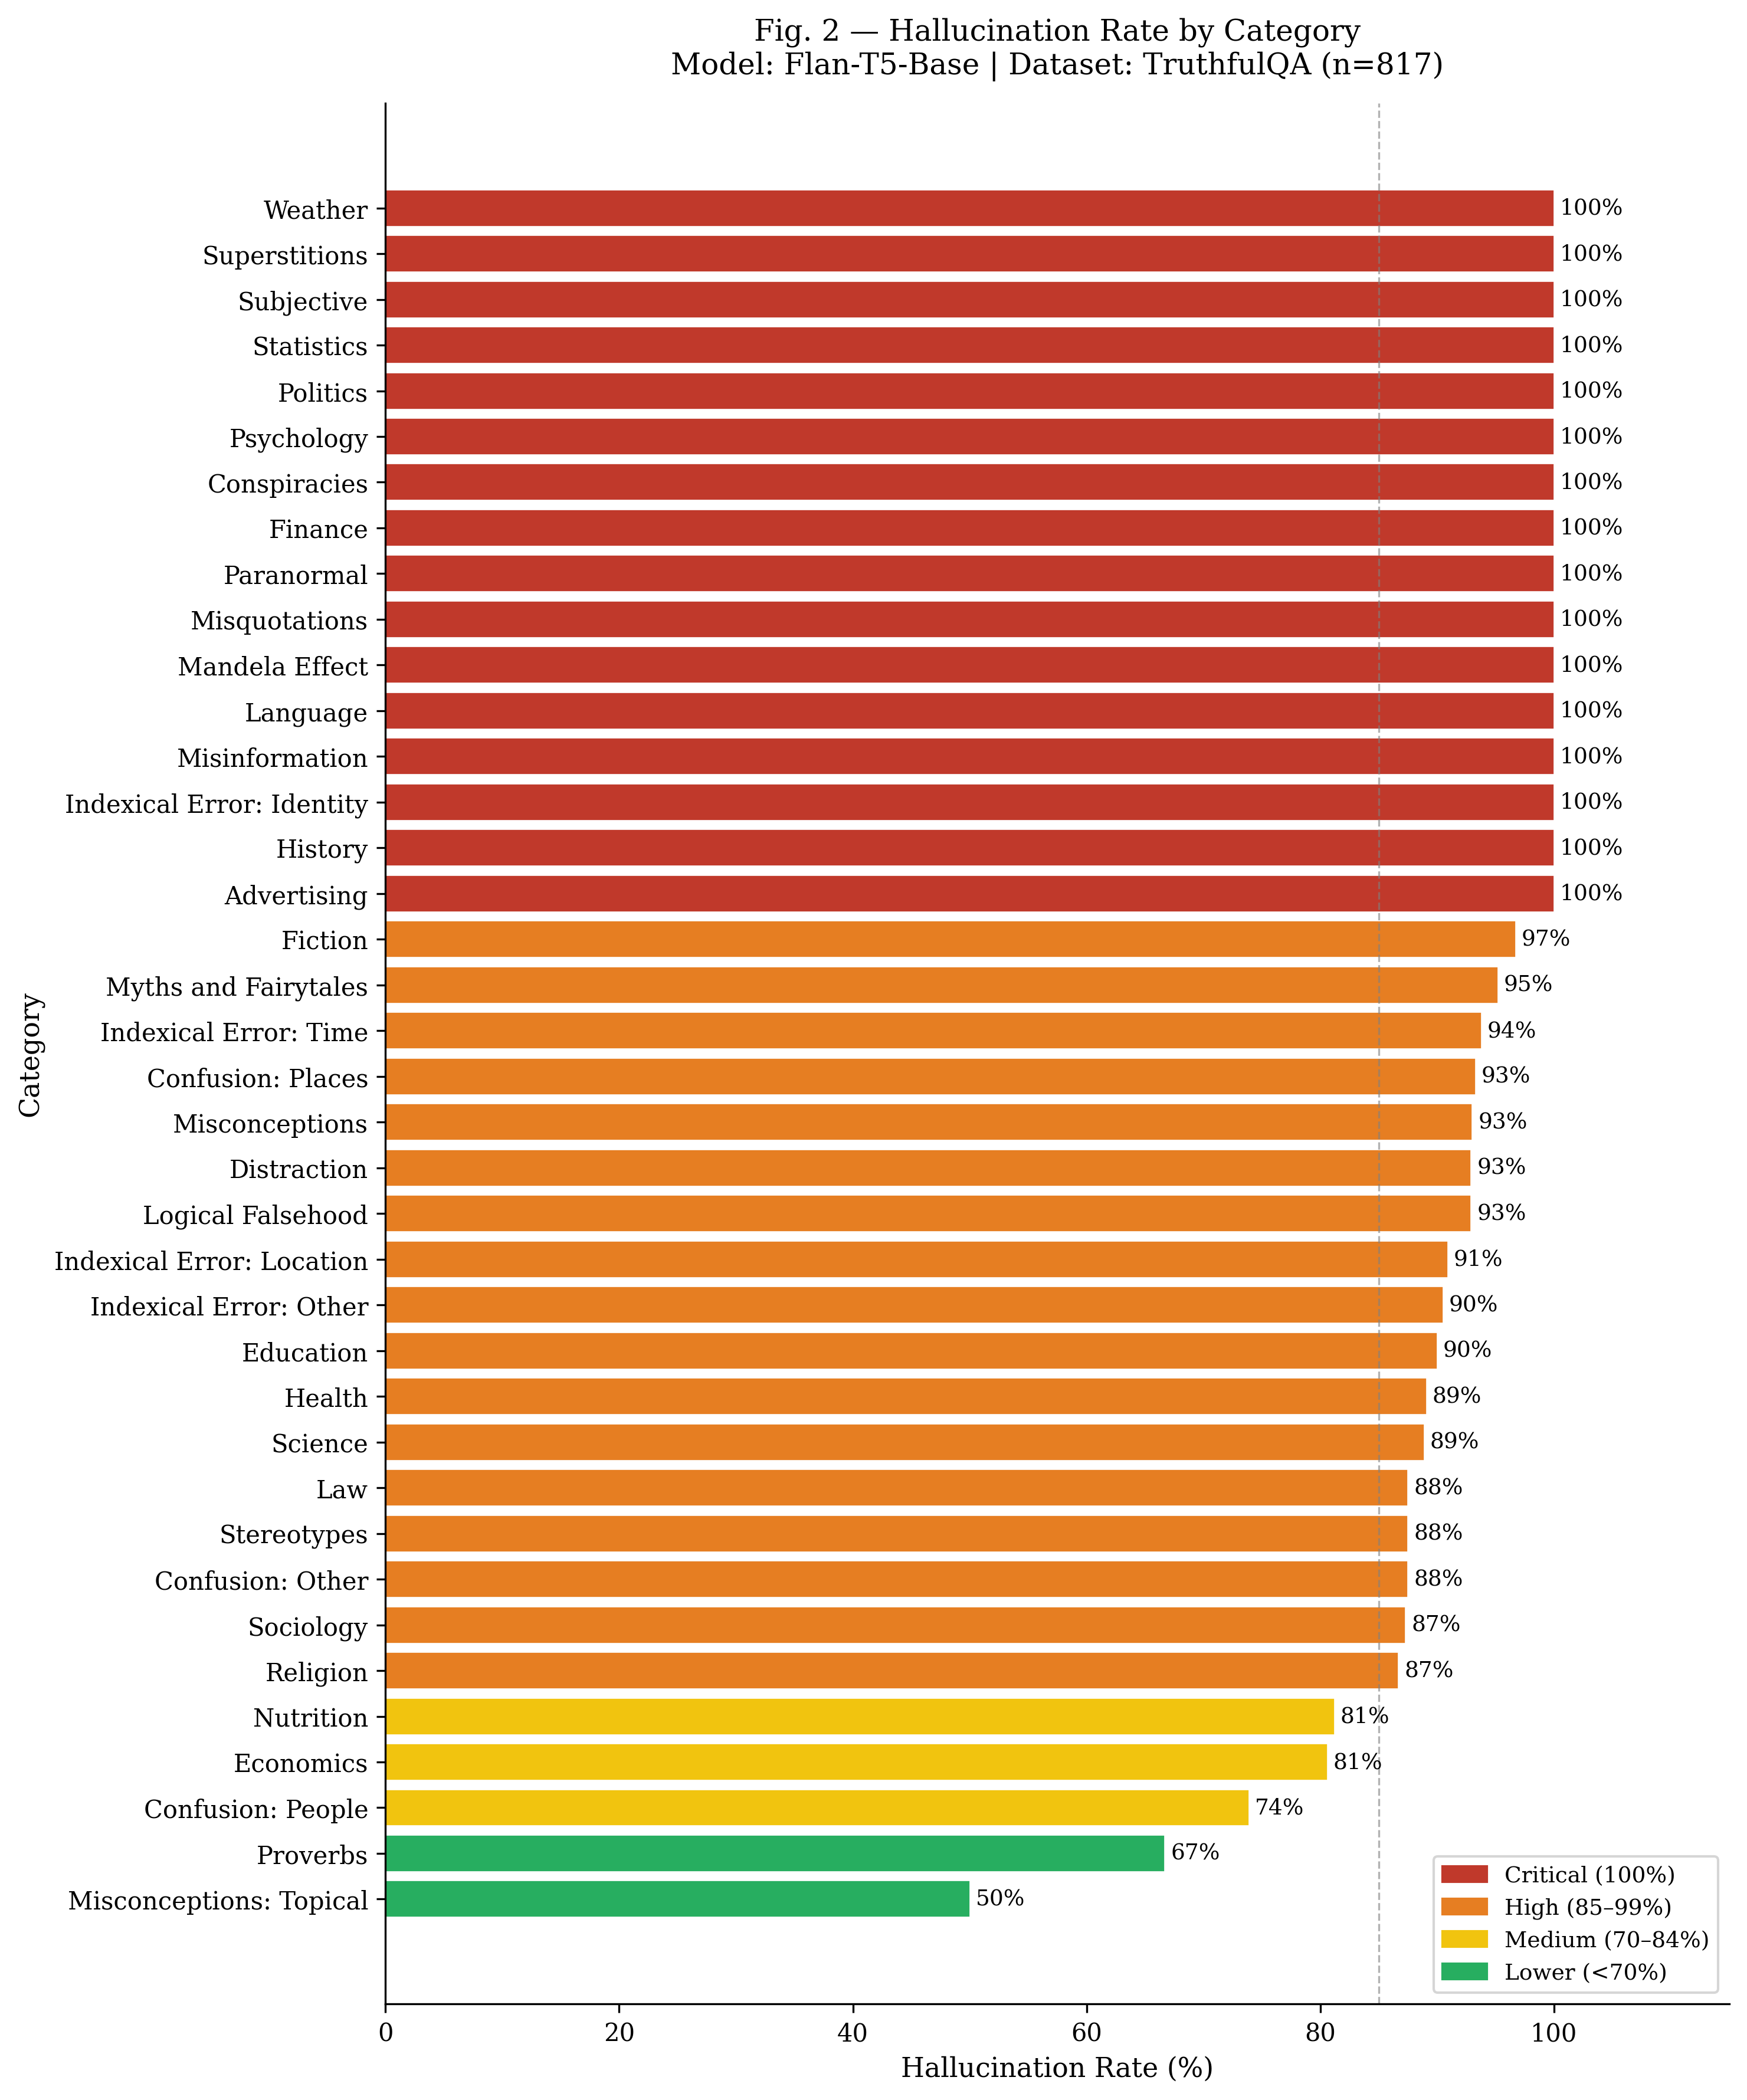

Saved: fig02_hallucination_rate_by_category.png


In [2]:
# ─── Cell 3: Fig 02 — Hallucination Rate by Category ─────────────────────────
#
# This is the most important figure in your paper.
# It shows which domains are most vulnerable to hallucination.
# Colour-coded by risk level: red=critical, orange=high, green=moderate

cat_stats = df.groupby('category').agg(
    total=('consensus_hallucinated', 'count'),
    hallucinated=('consensus_hallucinated', 'sum')
).reset_index()
cat_stats['rate'] = (cat_stats['hallucinated'] /
                     cat_stats['total'] * 100).round(1)
cat_stats = cat_stats.sort_values('rate', ascending=True)

# Assign risk colours
def get_color(rate):
    if rate == 100:
        return '#C0392B'   # Critical red
    elif rate >= 85:
        return '#E67E22'   # High orange
    elif rate >= 70:
        return '#F1C40F'   # Medium yellow
    else:
        return '#27AE60'   # Lower green

colors = [get_color(r) for r in cat_stats['rate']]

fig, ax = plt.subplots(figsize=(10, 12))

bars = ax.barh(cat_stats['category'], cat_stats['rate'],
               color=colors, edgecolor='white', linewidth=0.4)

# Add rate labels
for bar, rate in zip(bars, cat_stats['rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{rate:.0f}%', va='center', ha='left', fontsize=9)

# Legend
legend_patches = [
    mpatches.Patch(color='#C0392B', label='Critical (100%)'),
    mpatches.Patch(color='#E67E22', label='High (85–99%)'),
    mpatches.Patch(color='#F1C40F', label='Medium (70–84%)'),
    mpatches.Patch(color='#27AE60', label='Lower (<70%)')
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

ax.set_xlabel('Hallucination Rate (%)', fontsize=11)
ax.set_ylabel('Category', fontsize=11)
ax.set_title(
    'Fig. 2 — Hallucination Rate by Category\n'
    'Model: Flan-T5-Base | Dataset: TruthfulQA (n=817)',
    fontsize=12, pad=12
)
ax.set_xlim(0, 115)
ax.axvline(x=85, color='gray', linestyle='--',
           linewidth=0.8, alpha=0.6, label='85% threshold')

plt.tight_layout()
plt.savefig('figures/fig02_hallucination_rate_by_category.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig02_hallucination_rate_by_category.png")

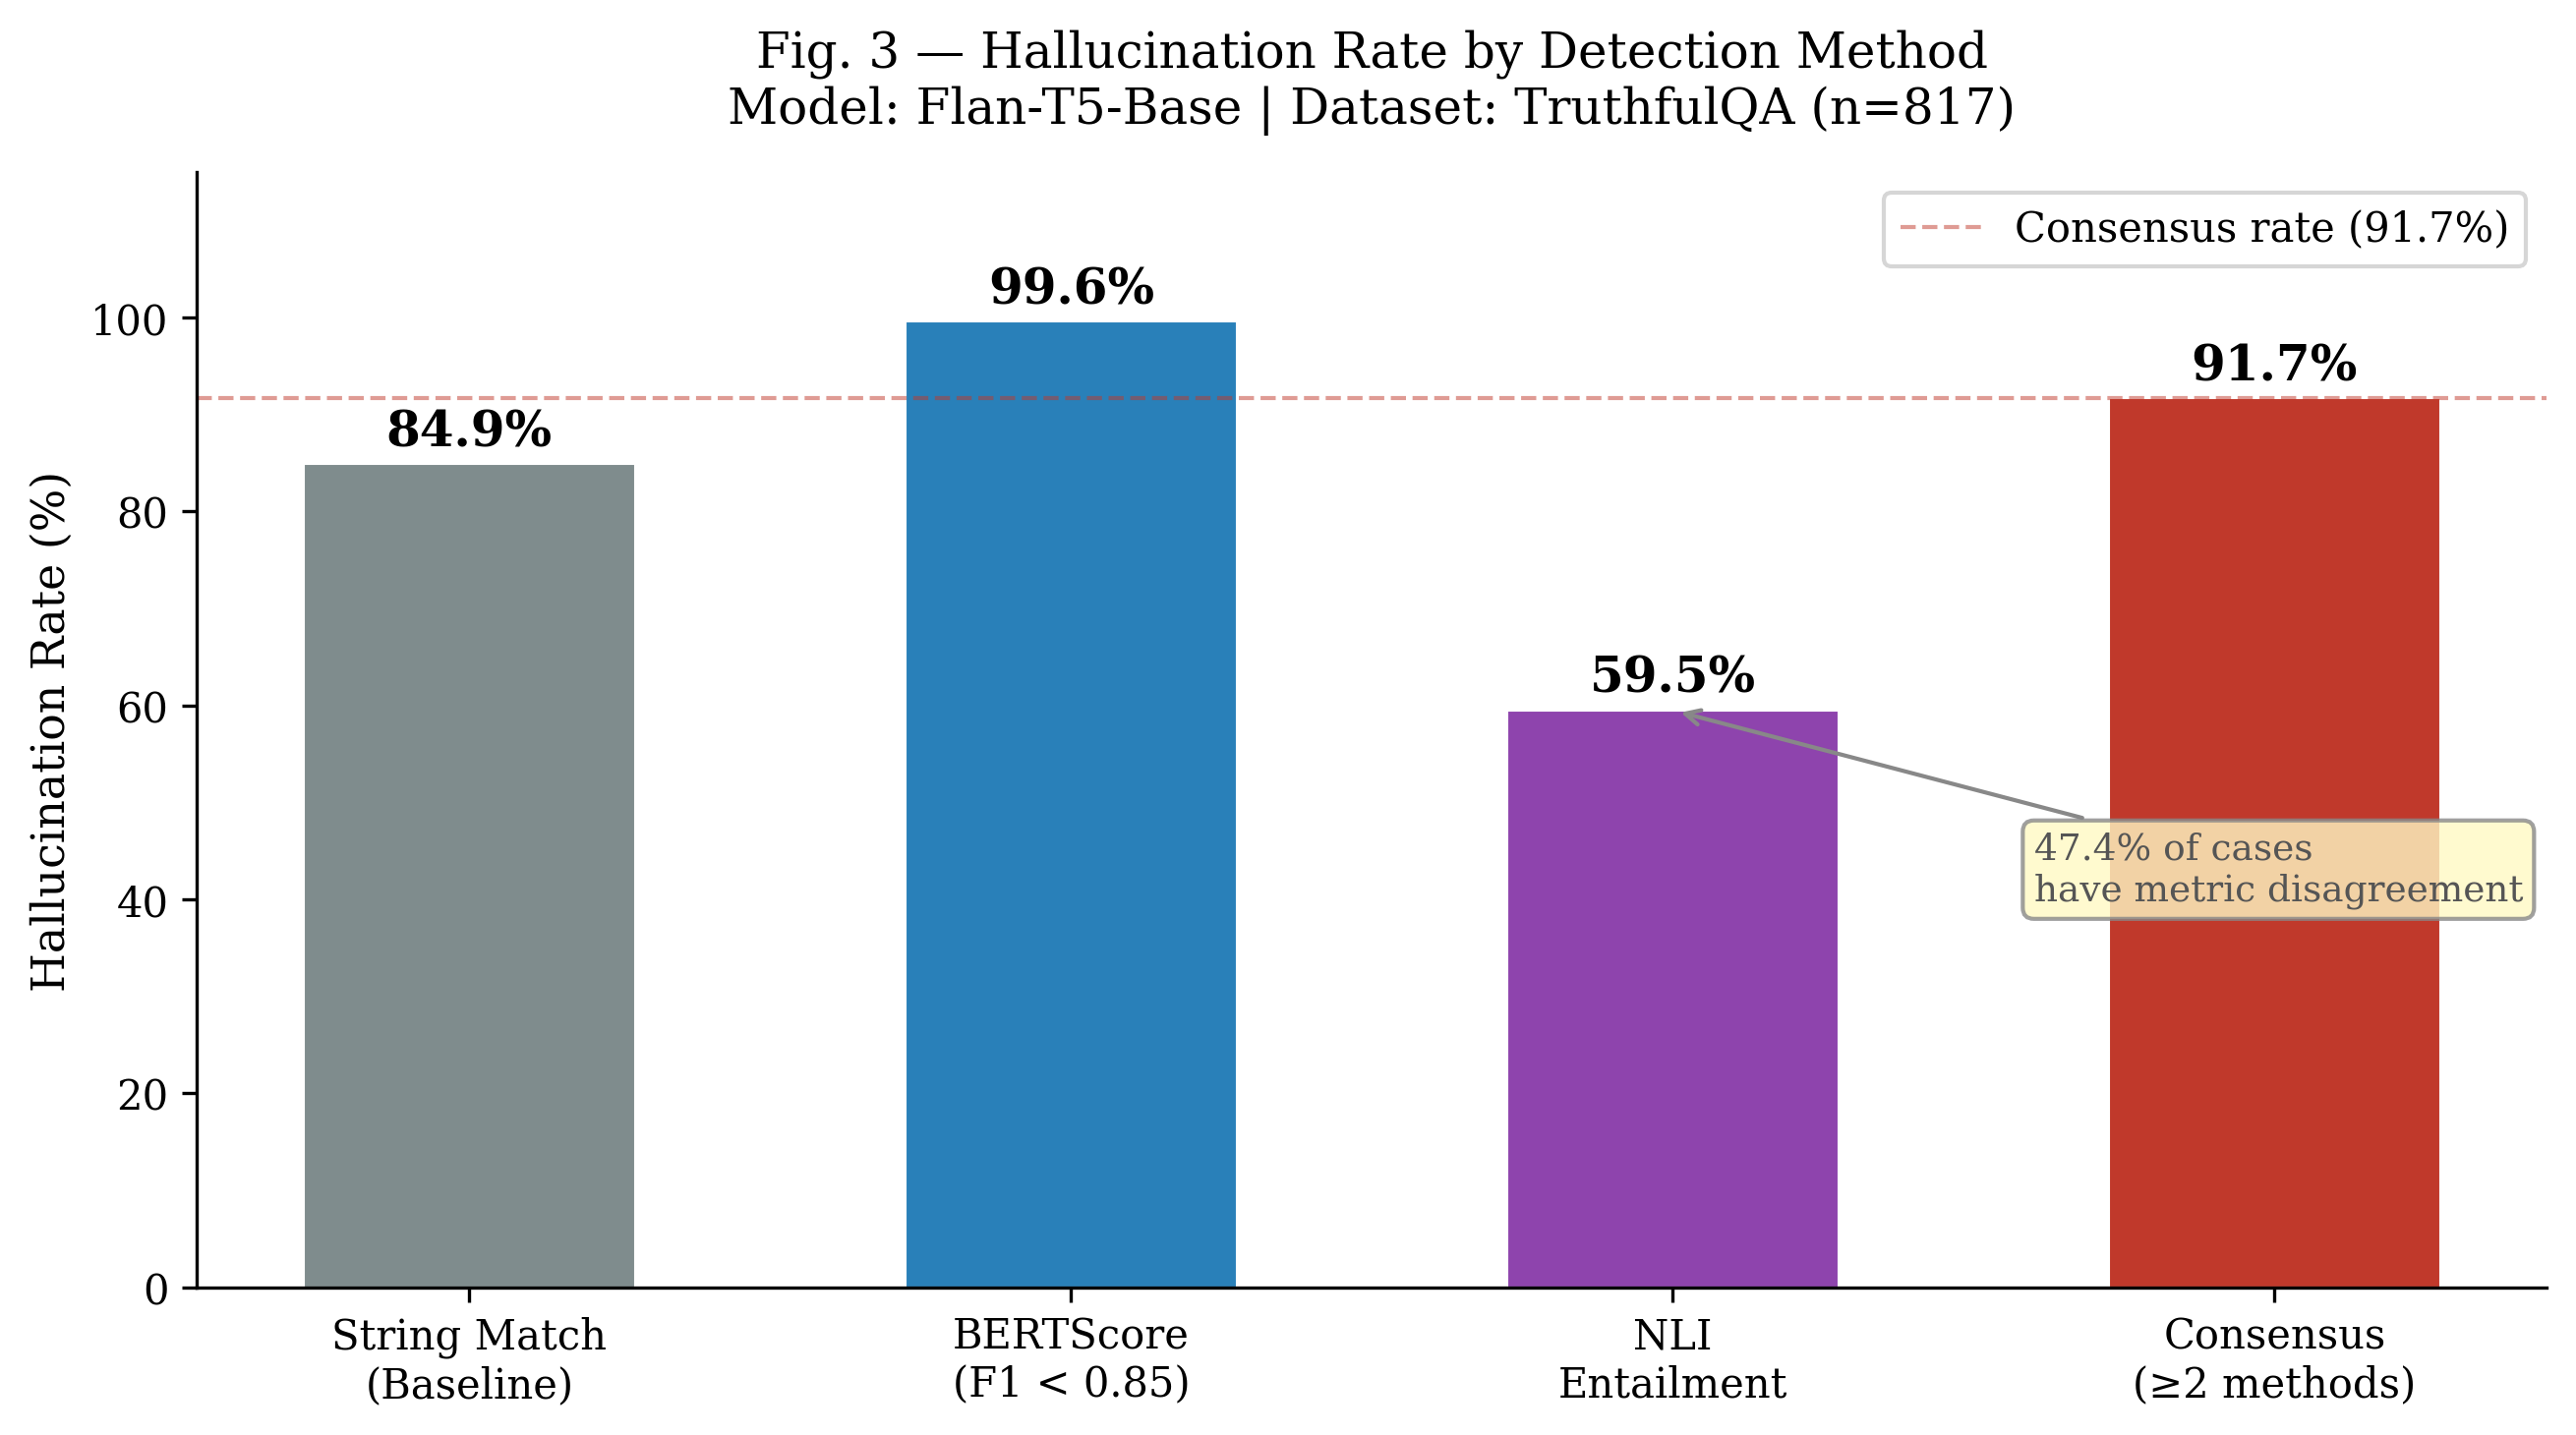

Saved: fig03_metric_comparison.png


In [3]:
# ─── Cell 4: Fig 03 — Metric Comparison ──────────────────────────────────────
#
# Shows the hallucination rate reported by each of the three methods.
# The disagreement between methods is visually obvious here —
# this is Figure 3 in your paper and supports your argument for
# consensus-based scoring.

methods = ['String Match\n(Baseline)', 'BERTScore\n(F1 < 0.85)',
           'NLI\nEntailment', 'Consensus\n(≥2 methods)']
rates = [84.9, 99.6, 59.5, 91.7]
colors_bar = ['#7F8C8D', '#2980B9', '#8E44AD', '#C0392B']

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(methods, rates, color=colors_bar,
              edgecolor='white', linewidth=0.5, width=0.55)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{rate}%', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.set_ylabel('Hallucination Rate (%)', fontsize=11)
ax.set_title(
    'Fig. 3 — Hallucination Rate by Detection Method\n'
    'Model: Flan-T5-Base | Dataset: TruthfulQA (n=817)',
    fontsize=12, pad=12
)
ax.set_ylim(0, 115)
ax.axhline(y=91.7, color='#C0392B', linestyle='--',
           linewidth=1, alpha=0.5, label='Consensus rate (91.7%)')
ax.legend(fontsize=10)

# Annotation explaining disagreement
ax.annotate(
    '47.4% of cases\nhave metric disagreement',
    xy=(2, 59.5), xytext=(2.6, 40),
    fontsize=9, color='#555',
    arrowprops=dict(arrowstyle='->', color='#888', lw=1),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF9C4',
              edgecolor='#888', alpha=0.8)
)

plt.tight_layout()
plt.savefig('figures/fig03_metric_comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig03_metric_comparison.png")

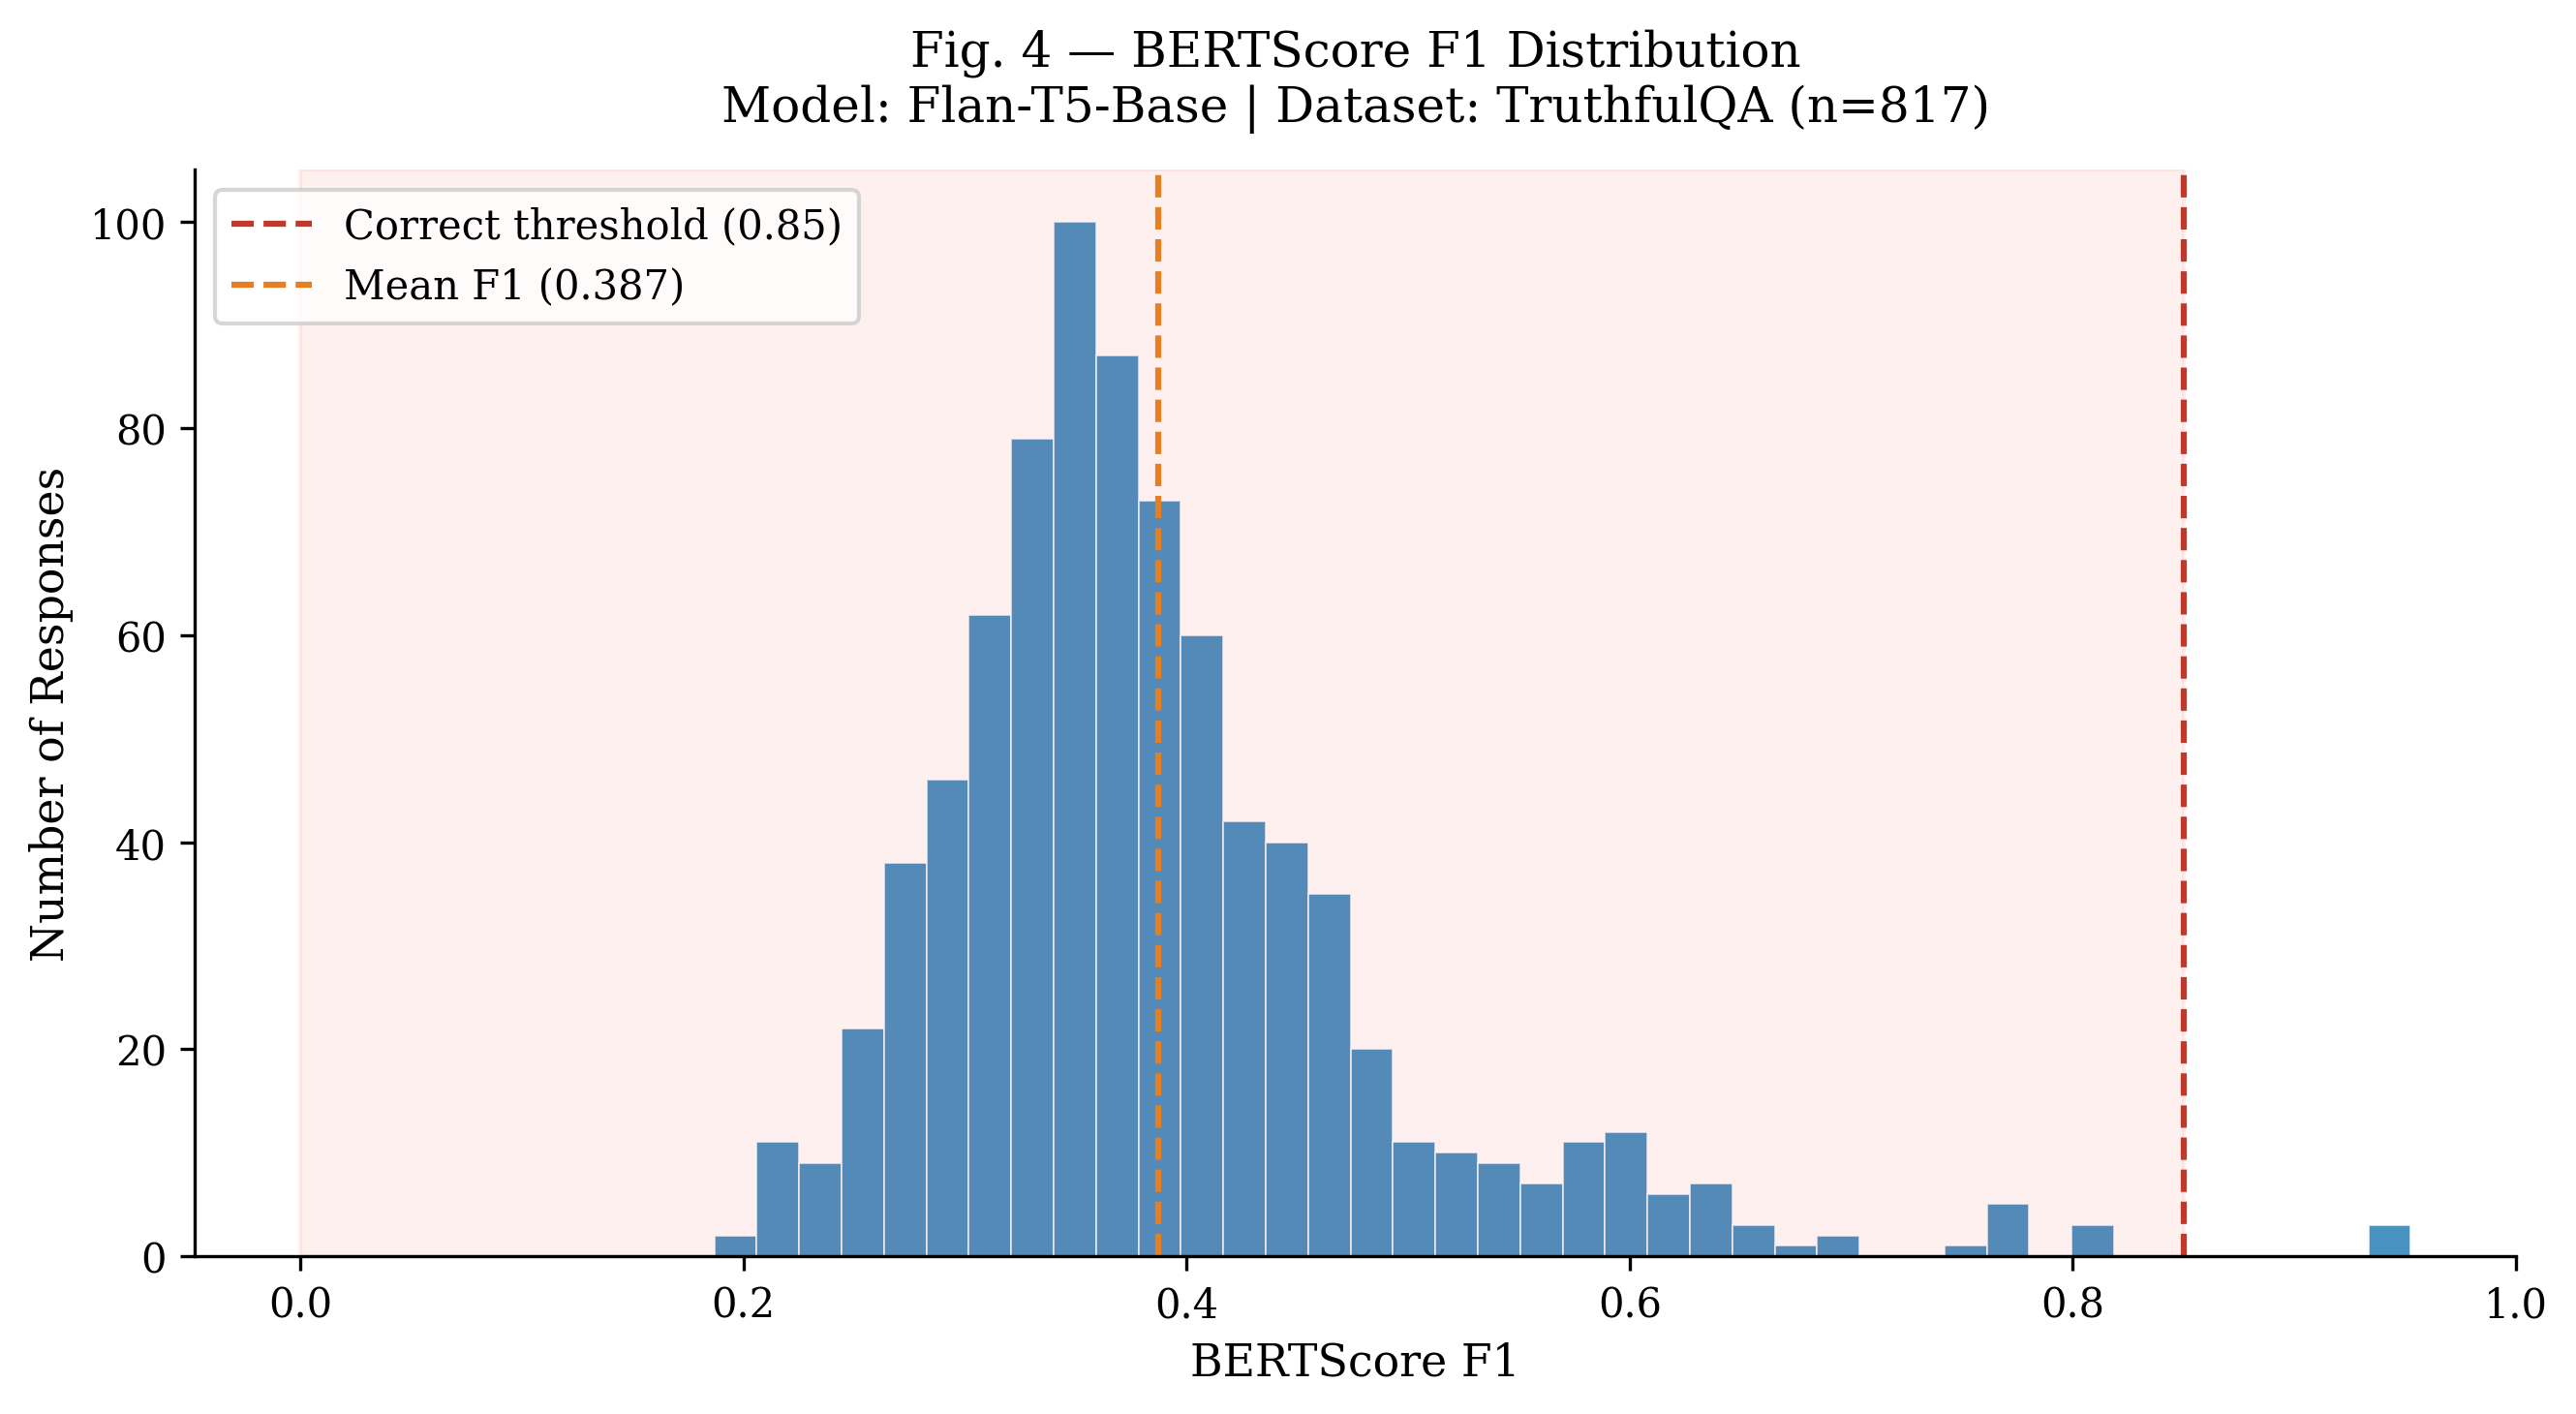

Saved: fig04_bertscore_distribution.png


In [4]:
# ─── Cell 5: Fig 04 — BERTScore F1 Distribution ──────────────────────────────
#
# Shows the full distribution of BERTScore F1 values.
# The peak around 0.35-0.45 tells the story:
# most responses are semantically far from the correct answer,
# but not completely random — they are plausible-wrong answers.

fig, ax = plt.subplots(figsize=(9, 5))

bert_f1s = df['bertscore_f1'].values

ax.hist(bert_f1s, bins=40, color='#2980B9',
        edgecolor='white', linewidth=0.4, alpha=0.85)

ax.axvline(x=0.85, color='#C0392B', linestyle='--',
           linewidth=1.5, label='Correct threshold (0.85)')
ax.axvline(x=np.mean(bert_f1s), color='#E67E22', linestyle='--',
           linewidth=1.5, label=f'Mean F1 ({np.mean(bert_f1s):.3f})')

ax.set_xlabel('BERTScore F1', fontsize=11)
ax.set_ylabel('Number of Responses', fontsize=11)
ax.set_title(
    'Fig. 4 — BERTScore F1 Distribution\n'
    'Model: Flan-T5-Base | Dataset: TruthfulQA (n=817)',
    fontsize=12, pad=12
)
ax.legend(fontsize=10)

# Shade hallucination region
ax.axvspan(0, 0.85, alpha=0.06, color='red', label='Hallucination zone')

plt.tight_layout()
plt.savefig('figures/fig04_bertscore_distribution.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig04_bertscore_distribution.png")

In [5]:
# ─── Cell 6: Table III — Full Category Statistics ─────────────────────────────
#
# This table goes into your paper as Table III.
# We export it as CSV so you can paste it into LaTeX easily.

from tabulate import tabulate

cat_full = df.groupby('category').agg(
    total=('id', 'count'),
    string_hallucinated=('string_match_score', lambda x: (x < 0.5).sum()),
    bert_hallucinated=('bertscore_f1', lambda x: (x < 0.85).sum()),
    nli_hallucinated=('nli_label', lambda x: (x == 'hallucinated').sum()),
    consensus_hallucinated=('consensus_hallucinated', 'sum'),
    mean_bertscore=('bertscore_f1', 'mean'),
    mean_nli_entailment=('nli_entailment_score', 'mean')
).reset_index()

cat_full['consensus_rate'] = (
    cat_full['consensus_hallucinated'] /
    cat_full['total'] * 100
).round(1)
cat_full['mean_bertscore'] = cat_full['mean_bertscore'].round(3)
cat_full['mean_nli_entailment'] = cat_full['mean_nli_entailment'].round(3)

cat_full = cat_full.sort_values('consensus_rate', ascending=False)

# Save as CSV
cat_full.to_csv('results/table3_category_statistics.csv', index=False)

print("TABLE III — Full Category Hallucination Statistics")
print(f"(Sorted by consensus hallucination rate)\n")

display_cols = ['category', 'total', 'consensus_hallucinated',
                'consensus_rate', 'mean_bertscore', 'mean_nli_entailment']
print(tabulate(cat_full[display_cols].head(20),
               headers=['Category', 'N', 'Hall.', 'Rate%',
                        'BERTScore', 'NLI Score'],
               tablefmt='grid', showindex=False))

print(f"\nFull table saved: results/table3_category_statistics.csv")

TABLE III — Full Category Hallucination Statistics
(Sorted by consensus hallucination rate)

+---------------------------+-----+---------+---------+-------------+-------------+
| Category                  |   N |   Hall. |   Rate% |   BERTScore |   NLI Score |
+===========================+=====+=========+=========+=============+=============+
| Advertising               |  13 |      13 |   100   |       0.327 |       0.5   |
+---------------------------+-----+---------+---------+-------------+-------------+
| Conspiracies              |  25 |      25 |   100   |       0.372 |       0.329 |
+---------------------------+-----+---------+---------+-------------+-------------+
| Language                  |  21 |      21 |   100   |       0.399 |       0.275 |
+---------------------------+-----+---------+---------+-------------+-------------+
| Indexical Error: Identity |   9 |       9 |   100   |       0.367 |       0.283 |
+---------------------------+-----+---------+---------+------------

In [6]:
# ─── Cell 7: Download Everything ──────────────────────────────────────────────

from google.colab import files

outputs = [
    'figures/fig02_hallucination_rate_by_category.png',
    'figures/fig03_metric_comparison.png',
    'figures/fig04_bertscore_distribution.png',
    'results/table3_category_statistics.csv'
]

for f in outputs:
    files.download(f)
    print(f"Downloaded: {f}")

print("\nMove figures to: p1-taxonomy-benchmark/figures/")
print("Move CSV to    : p1-taxonomy-benchmark/results/")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: figures/fig02_hallucination_rate_by_category.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: figures/fig04_bertscore_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: results/table3_category_statistics.csv

Move figures to: p1-taxonomy-benchmark/figures/
Move CSV to    : p1-taxonomy-benchmark/results/
